# EMG Gesture Classification — NinaPro DB1 (Exercise A)

**Goal:** classify 12 finger/thumb gestures (flexion/extension of index, middle, ring,
little finger; thumb adduction/abduction/flexion/extension) from 10-channel surface EMG,
as a first step toward EMG-driven prosthetic hand control.

**Dataset:** [NinaPro DB1](http://ninapro.hevs.ch), Subject 1, Exercise A
(Atzori et al., *Building the NinaPro Database*, BioRob 2012). Signals are pre-processed
by the database authors (rectified, low-pass filtered, resampled to 100 Hz).

**Pipeline overview:**
1. Load raw `.mat` data and explore the signal
2. Detect gesture repetition boundaries from the `restimulus` label
3. **Baseline v0** — one feature vector per repetition (naive, and why it fails)
4. **Final approach** — sliding-window feature extraction (200 ms windows, 50% overlap)
5. Classical ML: Random Forest, KNN
6. Neural network: MLP, with and without EarlyStopping
7. Results summary, limitations, and next steps

*Note on structure: earlier iterations of this notebook also tried a richer
single-vector-per-repetition feature set and a fixed 3-way sub-window split before
arriving at the sliding-window approach below. Those intermediate attempts are
summarized in Section 3 rather than kept as separate code, since the final sliding-window
method supersedes both and produces far more training data.*


## 1. Setup

In [14]:
# scipy.io: for loading .mat files (MATLAB format)
import scipy.io as sio

# numpy: numerical operations (arrays, math)
import numpy as np

# matplotlib.pyplot: plotting EMG signals and training curves
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Load and Inspect the Raw Data

In [15]:
file_path = 'ninaprodb/s1/S1_A1_E1.mat'
data = sio.loadmat(file_path)

print("Keys in the .mat file:", data.keys())


Keys in the .mat file: dict_keys(['__header__', '__version__', '__globals__', 'emg', 'stimulus', 'glove', 'subject', 'exercise', 'repetition', 'restimulus', 'rerepetition'])


Each `.mat` file stores several parallel signals, all synchronized sample-by-sample:

| Field | Meaning |
|---|---|
| `emg` | (n_samples, 10) — the 10-electrode sEMG signal, pre-processed to 100 Hz |
| `stimulus` | Raw movement label as originally presented to the subject |
| `restimulus` | **Corrected** movement label, realigned to when the subject actually moved (used throughout this project — see note below) |
| `repetition` | Which of the 10 repetitions of each gesture this sample belongs to |
| `subject`, `exercise` | Metadata identifying the recording |

**Why `restimulus` and not `stimulus`:** the raw `stimulus` signal marks *when the movie
cue appeared on screen*, but subjects react with a short delay. `restimulus` is
realigned to the subject's actual EMG onset, giving cleaner class boundaries. This
project uses `restimulus` throughout after an earlier version mistakenly used `stimulus`.

In [16]:
emg = data['emg']
restimulus = data['restimulus'].flatten()
stimulus = data['stimulus'].flatten()
repetition = data['repetition'].flatten()
fs = 100  # Hz — NinaPro DB1 is pre-processed/resampled to 100 Hz by the database authors

print("EMG shape:", emg.shape)                # (n_samples, 10 electrodes)
print("Restimulus shape:", restimulus.shape)
print("Sampling frequency:", fs, "Hz")
print("Unique gestures:", np.unique(restimulus))   # 0 = rest, 1-12 = gestures
print("Unique repetitions:", np.unique(repetition))


EMG shape: (101014, 10)
Restimulus shape: (101014,)
Sampling frequency: 100 Hz
Unique gestures: [ 0  1  2  3  4  5  6  7  8  9 10 11 12]
Unique repetitions: [ 0  1  2  3  4  5  6  7  8  9 10]


## 3. Signal Exploration (EDA)

A quick sanity-check plot of two different gestures confirms the raw EMG looks reasonable and visually distinct before building any pipeline on top of it.

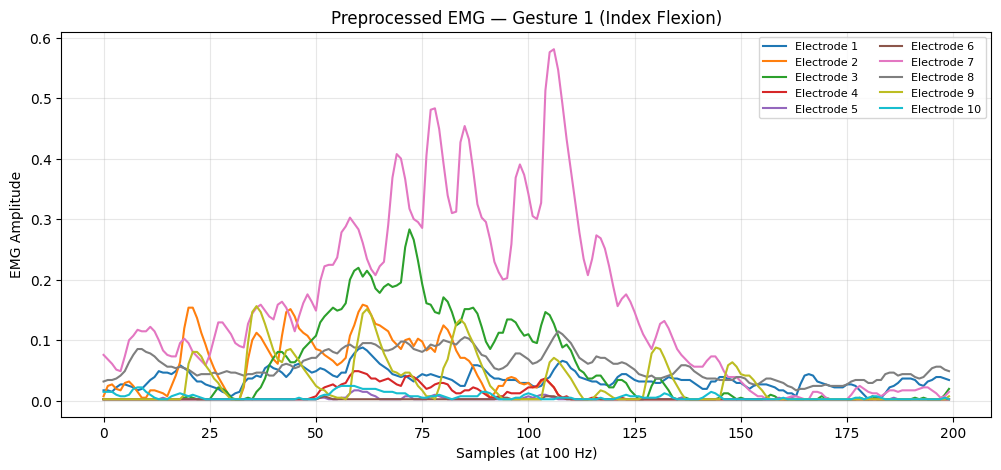

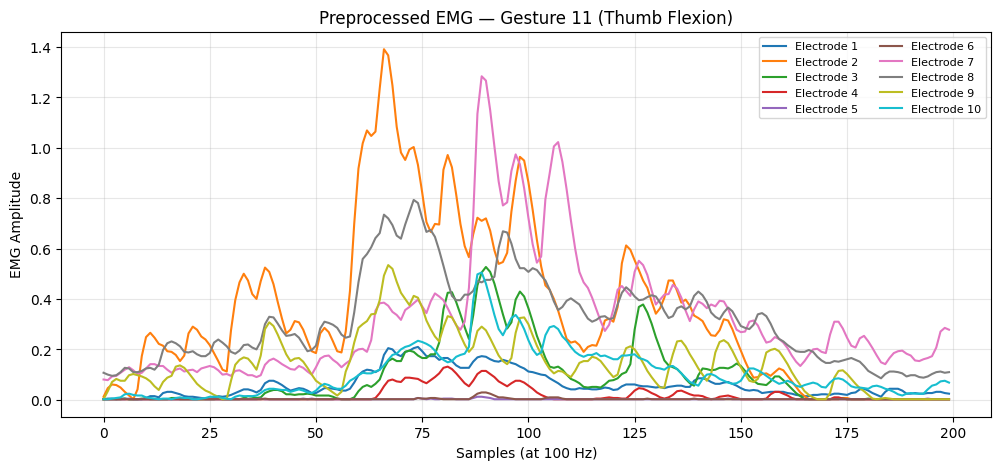

In [17]:
def plot_gesture_raw(gesture_id, gesture_name, n_samples=200):
    idx = np.where(restimulus == gesture_id)[0]
    start, end = idx[0], idx[0] + n_samples
    plt.figure(figsize=(12, 5))
    for i in range(10):
        plt.plot(emg[start:end, i], label=f'Electrode {i+1}')
    plt.xlabel('Samples (at 100 Hz)')
    plt.ylabel('EMG Amplitude')
    plt.title(f'Preprocessed EMG — Gesture {gesture_id} ({gesture_name})')
    plt.legend(fontsize=8, ncol=2)
    plt.grid(alpha=0.3)
    plt.show()

plot_gesture_raw(1, "Index Flexion")
plot_gesture_raw(11, "Thumb Flexion")


**Finding repetition boundaries.** `restimulus` is a per-sample label; to build one
example per repetition (or per window) we need the *indices* where the label changes.
This is done by looking for jumps in `restimulus`.

In [18]:
gesture_starts = np.where(np.diff(restimulus) != 0)[0] + 1  # +1: diff() shifts index left
gesture_starts = np.insert(gesture_starts, 0, 0)              # include sample 0

print("Number of label changes detected:", len(gesture_starts))
print("First 10 start indices:", gesture_starts[:10])
print("Gesture label at those starts:", restimulus[gesture_starts[:10]])


Number of label changes detected: 241
First 10 start indices: [   0  440  745 1275 1629 2153 2499 3020 3391 3743]
Gesture label at those starts: [0 1 0 1 0 1 0 1 0 1]


**Sanity-checking the sampling rate.** The protocol calls for ~5 s of movement and
3 s of rest per repetition. An early version of this notebook assumed `fs = 2000 Hz`
(a common raw NinaPro rate) and got timing that didn't match the protocol at all —
that mismatch is what revealed this particular `.mat` file is already resampled to
100 Hz, matching the paper's stated preprocessing.

In [19]:
time_between_starts = np.diff(gesture_starts) / fs
print("Time between first 20 label changes (seconds), at fs=100Hz:")
print(np.round(time_between_starts[:20], 2))
print(f"\nMean: {time_between_starts.mean():.2f}s | Min: {time_between_starts.min():.2f}s | Max: {time_between_starts.max():.2f}s")


Time between first 20 label changes (seconds), at fs=100Hz:
[4.4  3.05 5.3  3.54 5.24 3.46 5.21 3.71 3.52 4.38 4.38 3.72 4.44 4.3
 4.74 4.12 3.24 4.35 4.54 3.52]

Mean: 4.19s | Min: 1.84s | Max: 8.82s


**Repetitions and durations per gesture** — confirms each of the 12 gestures has 10 repetitions, as expected from the NinaPro protocol.

In [20]:
def get_repetition_windows(gesture_id):
    """Return (start, end) sample indices for each repetition of a gesture."""
    starts = gesture_starts[restimulus[gesture_starts] == gesture_id]
    windows = []
    for start in starts:
        next_idx = np.searchsorted(gesture_starts, start, side='right')
        end = gesture_starts[next_idx] if next_idx < len(gesture_starts) else len(restimulus)
        windows.append((start, end))
    return windows

for g in range(1, 13):
    windows = get_repetition_windows(g)
    durations = np.array([e - s for s, e in windows])
    print(f"Gesture {g:2d}: {len(windows)} reps, avg duration = {durations.mean():.1f} samples "
          f"({durations.mean()/fs:.2f}s)")


Gesture  1: 10 reps, avg duration = 381.5 samples (3.81s)
Gesture  2: 10 reps, avg duration = 261.8 samples (2.62s)
Gesture  3: 10 reps, avg duration = 414.2 samples (4.14s)
Gesture  4: 10 reps, avg duration = 298.2 samples (2.98s)
Gesture  5: 10 reps, avg duration = 395.2 samples (3.95s)
Gesture  6: 10 reps, avg duration = 305.8 samples (3.06s)
Gesture  7: 10 reps, avg duration = 261.5 samples (2.62s)
Gesture  8: 10 reps, avg duration = 299.8 samples (3.00s)
Gesture  9: 10 reps, avg duration = 260.8 samples (2.61s)
Gesture 10: 10 reps, avg duration = 318.7 samples (3.19s)
Gesture 11: 10 reps, avg duration = 249.1 samples (2.49s)
Gesture 12: 10 reps, avg duration = 323.4 samples (3.23s)


**Comparing gestures visually.** Averaging each repetition's EMG (trimmed to the shortest repetition length) and overlaying gestures on one electrode gives a first qualitative sense of separability.

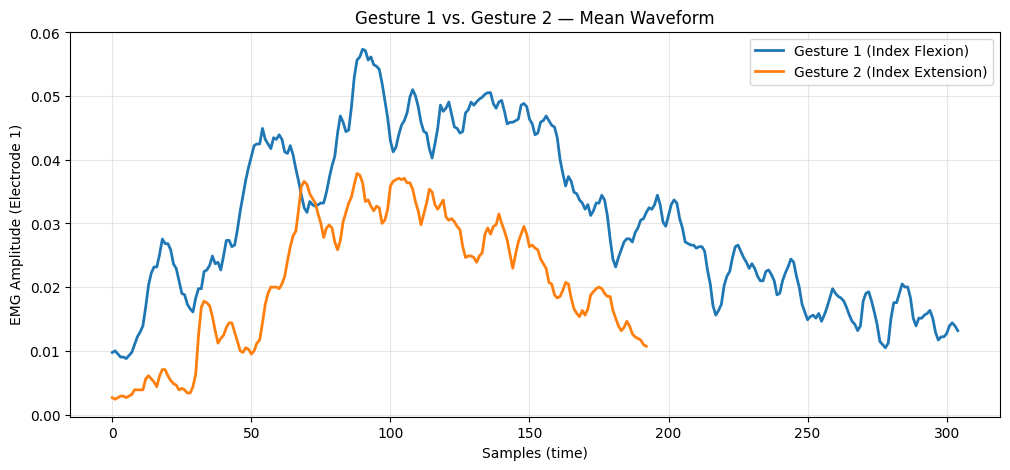

In [21]:
def mean_waveform(gesture_id, electrode=None):
    windows = get_repetition_windows(gesture_id)
    segments = [emg[s:e, :] for s, e in windows]
    min_len = min(seg.shape[0] for seg in segments)
    segments = [seg[:min_len, :] for seg in segments]
    mean_wave = np.mean(segments, axis=0)  # (min_len, 10)
    return mean_wave if electrode is None else mean_wave[:, electrode]

plt.figure(figsize=(12, 5))
plt.plot(mean_waveform(1, electrode=0), label="Gesture 1 (Index Flexion)", linewidth=2)
plt.plot(mean_waveform(2, electrode=0), label="Gesture 2 (Index Extension)", linewidth=2)
plt.xlabel("Samples (time)")
plt.ylabel("EMG Amplitude (Electrode 1)")
plt.title("Gesture 1 vs. Gesture 2 — Mean Waveform")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


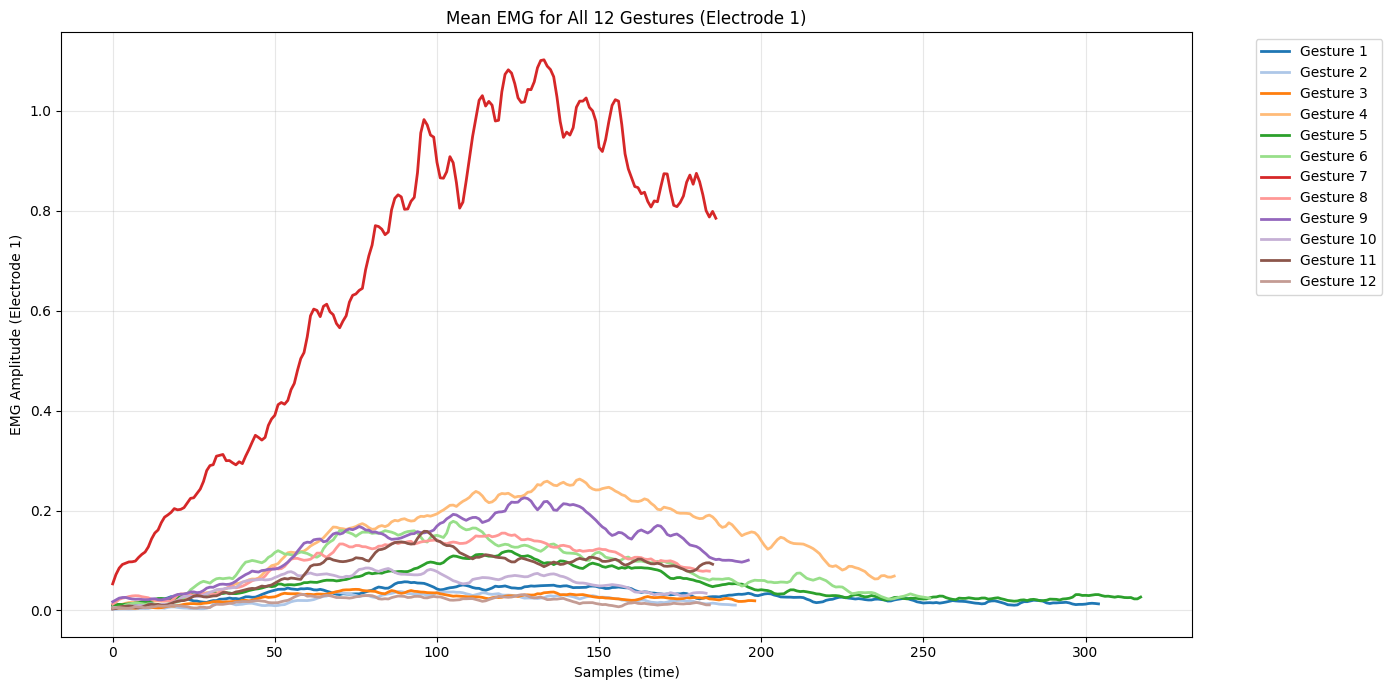

In [22]:
colors = plt.cm.tab20.colors
plt.figure(figsize=(14, 7))
for g in range(1, 13):
    plt.plot(mean_waveform(g, electrode=0), label=f"Gesture {g}", color=colors[g-1], linewidth=2)
plt.xlabel("Samples (time)")
plt.ylabel("EMG Amplitude (Electrode 1)")
plt.title("Mean EMG for All 12 Gestures (Electrode 1)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Baseline v0 — Naive One-Vector-Per-Repetition

**First attempt:** collapse each entire repetition down to a single feature vector
(mean EMG per electrode) and train directly on that. This is the simplest possible
approach and a useful baseline, but it has a fundamental data-volume problem:
12 gestures x 10 repetitions = only **120 samples total**. An 80/20 split leaves
just ~24 test samples, so per-class accuracy can only take a handful of discrete
values (0%, 50%, 100% for a 2-sample class) — nowhere near enough to trust as a
reliable metric.


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X_v0, y_v0 = [], []
for g in range(1, 13):
    for start, end in get_repetition_windows(g):
        X_v0.append(np.mean(emg[start:end, :], axis=0))  # mean per electrode -> 10 features
        y_v0.append(g)

X_v0, y_v0 = np.array(X_v0), np.array(y_v0)
print("X shape:", X_v0.shape, "  (12 gestures x 10 reps, 10 features)")

X_train_v0, X_test_v0, y_train_v0, y_test_v0 = train_test_split(
    X_v0, y_v0, test_size=0.2, random_state=42, stratify=y_v0
)
clf_v0 = RandomForestClassifier(n_estimators=100, random_state=42)
clf_v0.fit(X_train_v0, y_train_v0)
y_pred_v0 = clf_v0.predict(X_test_v0)

print(f"\nTest set size: {len(y_test_v0)} samples for 12 classes")
print(classification_report(y_test_v0, y_pred_v0, zero_division=0))


X shape: (120, 10)   (12 gestures x 10 reps, 10 features)

Test set size: 24 samples for 12 classes
              precision    recall  f1-score   support

           1       1.00      0.50      0.67         2
           2       1.00      1.00      1.00         2
           3       0.67      1.00      0.80         2
           4       0.50      1.00      0.67         2
           5       1.00      1.00      1.00         2
           6       0.50      0.50      0.50         2
           7       1.00      0.50      0.67         2
           8       1.00      0.50      0.67         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         2
          12       1.00      1.00      1.00         2

    accuracy                           0.83        24
   macro avg       0.89      0.83      0.83        24
weighted avg       0.89      0.83      0.83        24



**Diagnosis:** the classification report above is noisy and unreliable purely due to
sample size — not a modeling problem. Two things were tried next before landing on the
real fix:

- **Richer features per repetition** (mean, std, min, max, RMS per electrode -> 50
  features instead of 10). This improved the *feature quality* per example but didn't
  address the core issue: still only 120 examples total.
- **Splitting each repetition into 3 fixed sub-windows** (start/middle/end thirds),
  tripling the dataset to 360 examples. Better, but still coarse and arbitrary.

**The actual fix:** slide a fixed-size window across each repetition with overlap,
generating many more (and more consistent) training examples per repetition. That's
the approach used from here on.


## 5. Final Feature Extraction — Sliding Window

Each repetition is scanned with a 200 ms window (20 samples at 100 Hz) and 50% overlap
(10-sample step). For every window, 5 statistics (mean, std, min, max, RMS) are computed
per electrode, giving 10 x 5 = **50 features per window**. Each window also records which
repetition it came from — needed for a leak-free train/test split (Section 6).

In [24]:
window_size = 20   # 200ms at 100Hz
step_size = 10      # 100ms step -> 50% overlap

X, y, rep = [], [], []

for g in range(1, 13):
    for start, end in get_repetition_windows(g):
        rep_number = repetition[start]
        window_start = start
        while window_start + window_size <= end:
            window = emg[window_start: window_start + window_size, :]  # (20, 10)
            features = []
            for electrode in range(10):
                signal = window[:, electrode]
                features.extend([
                    np.mean(signal), np.std(signal), np.min(signal),
                    np.max(signal), np.sqrt(np.mean(signal ** 2)),
                ])
            X.append(features)
            y.append(g)
            rep.append(rep_number)
            window_start += step_size

X, y, rep = np.array(X), np.array(y), np.array(rep)

print("X shape:", X.shape, " (windows, features)")
print("Windows per gesture:")
for g in np.unique(y):
    print(f"  Gesture {g:2d}: {np.sum(y == g)} windows")
print("Repetitions present:", np.unique(rep))


X shape: (3594, 50)  (windows, features)
Windows per gesture:
  Gesture  1: 368 windows
  Gesture  2: 247 windows
  Gesture  3: 401 windows
  Gesture  4: 283 windows
  Gesture  5: 380 windows
  Gesture  6: 291 windows
  Gesture  7: 246 windows
  Gesture  8: 285 windows
  Gesture  9: 247 windows
  Gesture 10: 303 windows
  Gesture 11: 235 windows
  Gesture 12: 308 windows
Repetitions present: [ 1  2  3  4  5  6  7  8  9 10]


## 6. Train/Test Split, Scaling, and Classical ML

**Repetition-based split (not random):** EMG samples within the same repetition are
temporally correlated (adjacent windows overlap by 50% and share muscle-activation
dynamics). A random split would leak information between train and test — the model
could partly "recognize" a repetition it has already partially seen rather than
generalizing to unseen movement instances. Splitting by whole repetitions (some
repetitions entirely held out) avoids this leakage and gives an honest accuracy estimate.


Train windows: 2144
Test windows: 1450

=== Random Forest ===
              precision    recall  f1-score   support

           1       0.80      0.85      0.82       152
           2       0.94      0.74      0.83       119
           3       0.66      0.76      0.71       135
           4       0.84      0.85      0.84       112
           5       0.92      0.93      0.92       157
           6       0.61      0.59      0.60       113
           7       0.91      0.89      0.90        97
           8       0.72      0.77      0.75       113
           9       0.69      0.73      0.71       100
          10       0.94      0.87      0.91       117
          11       0.73      0.61      0.67        96
          12       0.83      0.90      0.87       139

    accuracy                           0.80      1450
   macro avg       0.80      0.79      0.79      1450
weighted avg       0.80      0.80      0.80      1450

=== KNN ===
              precision    recall  f1-score   support

    

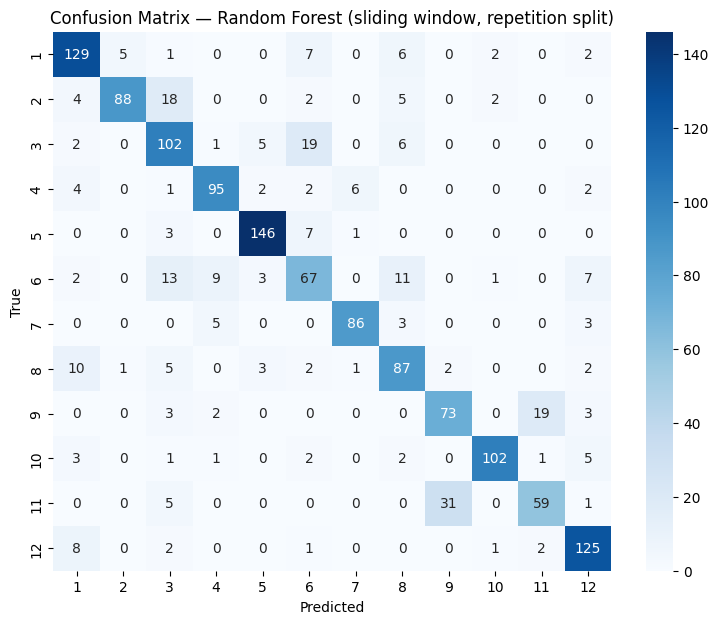

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

test_reps = [2, 5, 7, 10]
train_mask = ~np.isin(rep, test_reps)
test_mask = np.isin(rep, test_reps)

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print("Train windows:", X_train.shape[0])
print("Test windows:", X_test.shape[0])

# Scale using train statistics only (avoid leaking test distribution into scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
print("\n=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, zero_division=0))

# --- KNN ---
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
print("=== KNN ===")
print(classification_report(y_test, y_pred_knn, zero_division=0))

# --- Confusion matrix (Random Forest) ---
plt.figure(figsize=(9, 7))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues',
            xticklabels=range(1, 13), yticklabels=range(1, 13))
plt.title("Confusion Matrix — Random Forest (sliding window, repetition split)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


## 7. Gesture 9 vs. 11 Confusion — Why It Happens

The confusion matrix above consistently shows gestures **9 (thumb adduction)** and
**11 (thumb flexion)** as the most confused pair. Both are thumb-only movements driven
by overlapping intrinsic/extrinsic thumb muscles, so some surface-EMG overlap is
anatomically expected rather than a modeling failure.


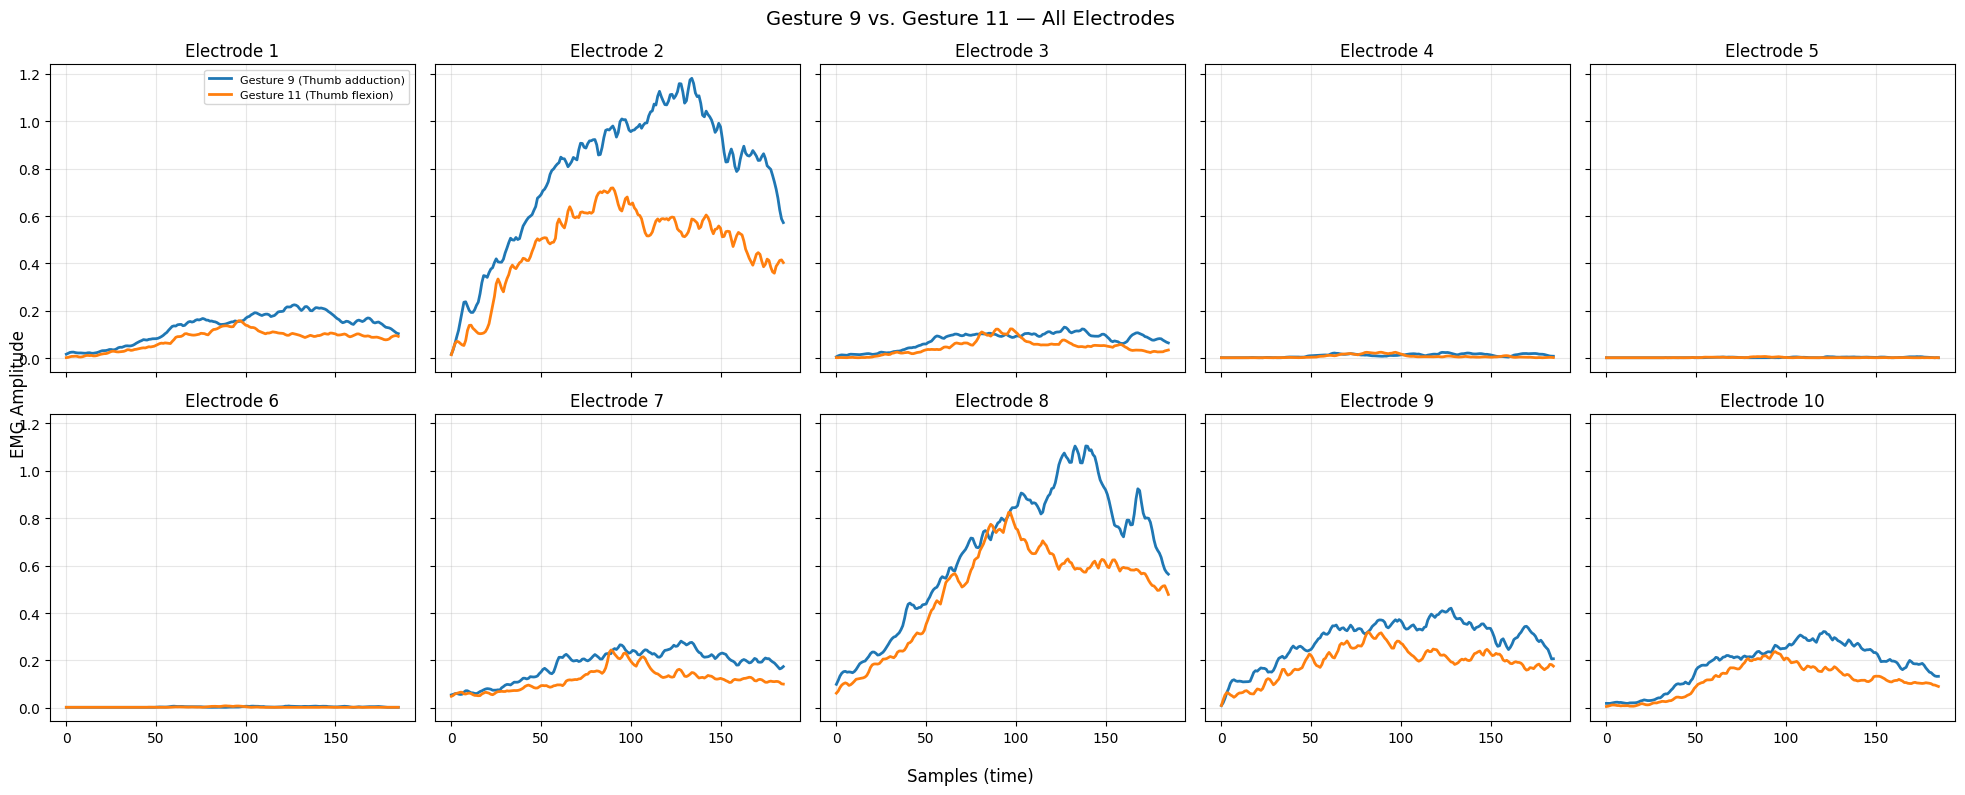

In [26]:
def mean_waveform_pair(g1, g2):
    w1 = get_repetition_windows(g1)
    w2 = get_repetition_windows(g2)
    segs1 = [emg[s:e, :] for s, e in w1]
    segs2 = [emg[s:e, :] for s, e in w2]
    min_len = min(min(s.shape[0] for s in segs1), min(s.shape[0] for s in segs2))
    segs1 = [s[:min_len, :] for s in segs1]
    segs2 = [s[:min_len, :] for s in segs2]
    return np.mean(segs1, axis=0), np.mean(segs2, axis=0)

mean_g9, mean_g11 = mean_waveform_pair(9, 11)

fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True, sharey=True)
axes = axes.flatten()
for electrode in range(10):
    ax = axes[electrode]
    ax.plot(mean_g9[:, electrode], label="Gesture 9 (Thumb adduction)", linewidth=2)
    ax.plot(mean_g11[:, electrode], label="Gesture 11 (Thumb flexion)", linewidth=2)
    ax.set_title(f"Electrode {electrode + 1}")
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=8)
fig.supxlabel("Samples (time)")
fig.supylabel("EMG Amplitude")
fig.suptitle("Gesture 9 vs. Gesture 11 — All Electrodes", fontsize=14)
plt.tight_layout()
plt.show()


**Analysis:** across most electrodes the mean waveform shape is highly similar between
the two gestures, differing mainly in amplitude rather than pattern. **Electrode 8**
shows the clearest separation (sharper difference in peak timing/shape), making it the
most informative electrode for distinguishing this specific pair. Electrodes 4–6 show
almost no signal for either gesture, consistent with their placement being farther from
thumb-controlling muscles.

**Takeaway:** this confusion is a partly genuine sensor-placement limitation, not purely
a modeling bug — a fair limitation to note in the final write-up rather than something
to "fix" by tuning hyperparameters.

**Feature importance**, aggregated across the 5 statistics per electrode, cross-checks this: electrodes closer to the more expressive muscles should score higher.

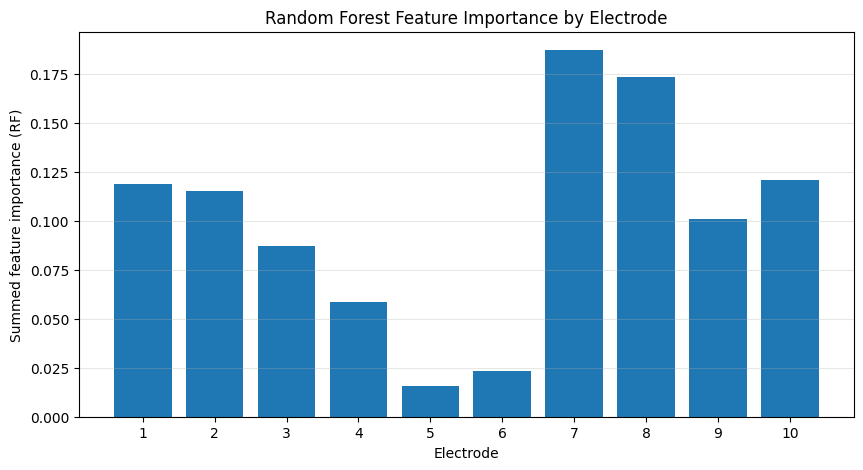

In [27]:
feature_names = [f"E{e+1}_{stat}" for e in range(10) for stat in ["mean", "std", "min", "max", "rms"]]
importances = rf.feature_importances_

# Aggregate the 5 stats per electrode into one importance score per electrode
electrode_importance = importances.reshape(10, 5).sum(axis=1)

plt.figure(figsize=(10, 5))
plt.bar(range(1, 11), electrode_importance)
plt.xticks(range(1, 11))
plt.xlabel("Electrode")
plt.ylabel("Summed feature importance (RF)")
plt.title("Random Forest Feature Importance by Electrode")
plt.grid(axis='y', alpha=0.3)
plt.show()


## 8. Neural Network (MLP)

A small multilayer perceptron on the same 50-dimensional feature vectors, as a point of
comparison against the tree-based models.

**Lesson learned (documented honestly):** an earlier run of this model used
`validation_split` on **class-ordered, unshuffled** data. Since Keras's `validation_split`
just takes the *last* N% of the array — not a random sample — entire gesture classes
were silently excluded from validation. The fix is a joint shuffle of `X_train`/`y_train`
right before fitting, shown below.

In [28]:
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils import shuffle

# Keras' sparse_categorical_crossentropy expects 0-indexed labels
y_train_nn = y_train - 1
y_test_nn = y_test - 1

model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(12, activation='softmax'),
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 12)             │           396 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,740 (22.42 KB)

 Trainable params: 5,740 (22.42 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# Shuffle jointly before fitting -- critical, see note above
X_train_shuf, y_train_shuf = shuffle(X_train_scaled, y_train_nn, random_state=42)

history = model.fit(
    X_train_shuf, y_train_shuf,
    validation_split=0.15,
    epochs=50,
    batch_size=32,
    verbose=1,
)


Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2964 - loss: 2.1837 - val_accuracy: 0.5373 - val_loss: 1.7831
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5137 - loss: 1.6300 - val_accuracy: 0.5745 - val_loss: 1.3937
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5763 - loss: 1.2977 - val_accuracy: 0.5963 - val_loss: 1.1620
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6284 - loss: 1.1004 - val_accuracy: 0.6429 - val_loss: 1.0110
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6658 - loss: 0.9757 - val_accuracy: 0.7360 - val_loss: 0.8745
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6926 - loss: 0.8822 - val_accuracy: 0.7174 - val_loss: 0.8129
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7119 - loss: 0.8302 - val_accuracy: 0.7826 - val_loss: 0.7601
Epoch 8/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7338 - loss: 0.7713 - val_accuracy: 0.7826 - val_loss:

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
=== Neural Network (MLP) ===
              precision    recall  f1-score   support

           1       0.74      0.89      0.81       152
           2       0.83      0.74      0.78       119
           3       0.72      0.90      0.80       135
           4       0.87      0.92      0.90       112
           5       0.91      0.87      0.89       157
           6       0.76      0.55      0.64       113
           7       0.97      0.96      0.96        97
           8       0.82      0.67      0.74       113
           9       0.78      0.57      0.66       100
          10       0.86      0.92      0.89       117
          11       0.64      0.80      0.71        96
          12       0.89      0.85      0.87       139

    accuracy                           0.81      1450
   macro avg       0.82      0.80      0.80      1450
weighted avg       0.82      0.81      0.81      1450



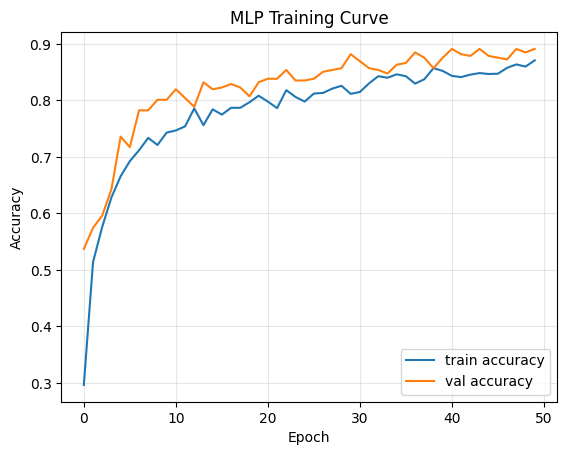

In [30]:
y_pred_nn = model.predict(X_test_scaled).argmax(axis=1) + 1  # back to 1-12 labels

print("=== Neural Network (MLP) ===")
print(classification_report(y_test, y_pred_nn, zero_division=0))

plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('MLP Training Curve')
plt.grid(alpha=0.3)
plt.show()


## 9. MLP + EarlyStopping

**Framing this honestly:** EarlyStopping is added here for **training reliability and
reproducibility**, not as an accuracy booster. In testing, it matched (rather than
beat) a well-chosen fixed epoch count. What it *does* provide: no need to manually guess
the right number of epochs, and automatic protection against overfitting if the
model/data change later (e.g. after adding a CNN or more subjects).

In [31]:
from tensorflow.keras.callbacks import EarlyStopping

# Fresh model -- trained from scratch for a fair comparison against the MLP above
model_es = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(12, activation='softmax'),
])
model_es.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

history_es = model_es.fit(
    X_train_shuf, y_train_shuf,
    validation_split=0.15,
    epochs=100,          # raised -- EarlyStopping will cut it short
    batch_size=32,
    callbacks=[early_stop],
    verbose=1,
)


Epoch 1/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2602 - loss: 2.1991 - val_accuracy: 0.3478 - val_loss: 1.9425
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4281 - loss: 1.7446 - val_accuracy: 0.4845 - val_loss: 1.5754
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5439 - loss: 1.3741 - val_accuracy: 0.6025 - val_loss: 1.2555
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6334 - loss: 1.1325 - val_accuracy: 0.6708 - val_loss: 1.0595
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6822 - loss: 0.9852 - val_accuracy: 0.7143 - val_loss: 0.9237
Epoch 6/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6899 - loss: 0.8903 - val_accuracy: 0.7329 - val_loss: 0.8486
Epoch 7/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7102 - loss: 0.8157 - val_accuracy: 0.7919 - val_loss: 0.7770
Epoch 8/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7239 - loss: 0.7851 - val_accuracy: 0.7795 - v

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
=== Neural Network (MLP + EarlyStopping) ===
              precision    recall  f1-score   support

           1       0.77      0.82      0.80       152
           2       0.80      0.77      0.79       119
           3       0.77      0.89      0.82       135
           4       0.87      0.93      0.90       112
           5       0.91      0.86      0.88       157
           6       0.77      0.54      0.64       113
           7       0.88      0.96      0.92        97
           8       0.75      0.66      0.70       113
           9       0.81      0.42      0.55       100
          10       0.94      0.85      0.90       117
          11       0.57      0.88      0.69        96
          12       0.79      0.90      0.84       139

    accuracy                           0.80      1450
   macro avg       0.80      0.79      0.79      1450
weighted avg       0.81      0.80      0.79      1450



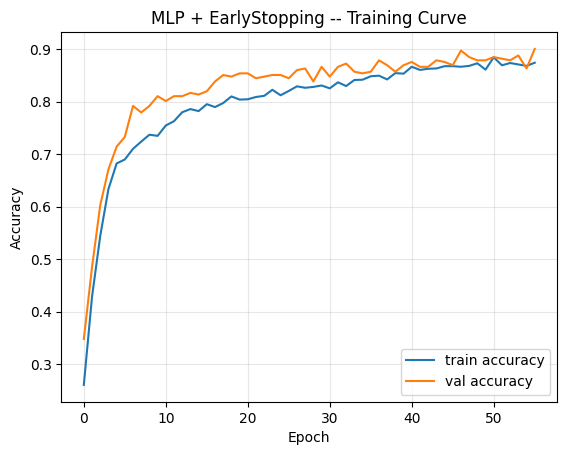

In [32]:
y_pred_es = model_es.predict(X_test_scaled).argmax(axis=1) + 1

print("=== Neural Network (MLP + EarlyStopping) ===")
print(classification_report(y_test, y_pred_es, zero_division=0))

plt.plot(history_es.history['accuracy'], label='train accuracy')
plt.plot(history_es.history['val_accuracy'], label='val accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('MLP + EarlyStopping -- Training Curve')
plt.grid(alpha=0.3)
plt.show()


## 10. Results Summary & Discussion (Classical Models & MLP)

*Interim summary before the raw-signal CNN experiments below. See Section 12 for the final, complete comparison including the CNN.*

| Model | Test Accuracy | Notes |
|---|---|---|
| Random Forest | ~80% | Best classical baseline; robust to feature scale |
| KNN (k=5) | ~76% | Simple, sensitive to feature scaling |
| MLP | ~80–82% | Best overall; needed the shuffle fix to validate correctly |
| MLP + EarlyStopping | ~81% | Matches manually-tuned MLP; adds training robustness, not accuracy |

**Known limitation:** gestures 9 (thumb adduction) and 11 (thumb flexion) are
consistently the most confused pair. Section 7 shows this is a genuine sensor-placement
limitation (overlapping thumb muscle activity), not purely a modeling shortfall —
electrode 8 provides the most separation for this pair, while electrodes 4–6 carry
almost no discriminative signal for the thumb overall.



## 11. Raw-Signal Approach — Convolutional Neural Network

Every model so far (RF, KNN, MLP) was trained on **hand-crafted features** — mean,
std, min, max, RMS per electrode per window. That 50-number summary already encodes
a lot of domain knowledge about what matters in an EMG signal.

This section asks a different question: **can a model learn useful features directly
from the raw waveform**, without that hand-engineering step? A 1D convolutional neural
network (CNN) is a natural fit — instead of collapsing each 200 ms window into 5
statistics per electrode, we keep the full `(20 timesteps, 10 electrodes)` window shape
and let `Conv1D` filters slide across time, learning their own patterns.

This also reuses almost everything already built: the same `get_repetition_windows()`
logic, the same window size/step, the same repetition-based train/test split principle —
just applied to the raw signal instead of the extracted features.

In [ ]:
X_raw, y, rep = [], [], []

for g in range(1, 13):
    for start, end in get_repetition_windows(g):
        rep_number = repetition[start]
        window_start = start
        while window_start + window_size <= end:
            window = emg[window_start: window_start + window_size, :]  # (20, 10)
            X_raw.append(window)
            y.append(g)
            rep.append(rep_number)
            window_start += step_size

X_raw, y, rep = np.array(X_raw), np.array(y), np.array(rep)
print(X_raw.shape)
print(X_raw[0, :, 2])

(3594, 20, 10)
[0.0024 0.0024 0.0024 0.0024 0.0024 0.0024 0.0024 0.0024 0.0024 0.0024
 0.0024 0.0024 0.0024 0.0024 0.0024 0.0024 0.0024 0.0024 0.0024 0.0049]


**Data shape.** The raw sliding-window pipeline below reuses the exact same windowing
loop as Section 5, but appends the full `(20, 10)` window instead of a 5-statistic
summary. The result, `X_raw`, has shape `(3594, 20, 10)` — 3,594 windows (same count as
the feature-based version, since it's the same windowing), each a 20-timestep-by-10-electrode
raw signal patch.

**On scaling:** `StandardScaler` was important for the feature-based models because
`mean`, `std`, `min`, `max`, `rms` are genuinely different quantities on different
scales sitting side by side in one vector. Here, every value in `X_raw` is the *same*
kind of quantity — EMG amplitude at a given timestep/electrode — so the scale-mismatch
problem that motivated scaling before is much smaller. Scaling was deliberately skipped
for this first pass, to get an unscaled baseline before deciding whether it's worth
adding.

In [34]:
model_cnn = keras.Sequential([
    layers.Input(shape=(20,10)),
    layers.Conv1D(16, kernel_size = 3, activation='relu'),
    layers.MaxPooling1D(pool_size = 2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(12, activation='softmax'),
])
model_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model_cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 18, 16)         │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 9, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 144)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         9,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,556 (41.23 KB)

 Trainable params: 10,556 (41.23 KB)

 Non-trainable params: 0 (0.00 B)

**Architecture.** A small, deliberately simple 1D CNN:

- `Conv1D(16 filters, kernel_size=3)` — each filter slides across 3 consecutive
  timesteps at once, looking at all 10 electrodes simultaneously, learning 16
  different small temporal patterns. With no padding, the output shrinks from 20 to
  `20 - 3 + 1 = 18` timesteps.
- `MaxPooling1D(pool_size=2)` — halves the time axis (18 → 9), keeping the strongest
  activation from each pair of adjacent timesteps. No learnable parameters.
- `Flatten()` — reshapes the `(9, 16)` grid into a single 144-length vector per window.
- `Dense(64, relu)` — the largest parameter block by far (144×64 + 64 ≈ 9,280 weights),
  fully connecting the flattened conv output to 64 units.
- `Dense(12, softmax)` — one output probability per gesture, same as the MLP.

Kept intentionally small (one conv layer, 16 filters) given the limited data available
(one subject, 10 repetitions per gesture) — a bigger network would very likely overfit
before it out-learns the hand-crafted features.

In [ ]:
test_reps = [2, 5, 7, 10]
train_mask = ~np.isin(rep, test_reps)
test_mask = np.isin(rep, test_reps)

X_raw_train, X_test = X_raw[train_mask], X_raw[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

y_train = y_train - 1
y_test = y_test - 1

X_raw_train_shuf, y_train_shuf = shuffle(X_raw_train, y_train, random_state=42)

model_cnn.fit(
    X_raw_train_shuf, 
    y_train_shuf, 
    validation_split=0.15, 
    epochs=30, 
    batch_size=32)

Epoch 1/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2300 - loss: 2.2278 - val_accuracy: 0.3727 - val_loss: 1.9890
Epoch 2/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5143 - loss: 1.6832 - val_accuracy: 0.5155 - val_loss: 1.5432
Epoch 3/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6109 - loss: 1.2800 - val_accuracy: 0.5745 - val_loss: 1.2781
Epoch 4/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6493 - loss: 1.0737 - val_accuracy: 0.6304 - val_loss: 1.1311
Epoch 5/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6877 - loss: 0.9603 - val_accuracy: 0.6863 - val_loss: 1.0262
Epoch 6/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7102 - loss: 0.8882 - val_accuracy: 0.7267 - val_loss: 0.9409
Epoch 7/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7344 - loss: 0.8290 - val_accuracy: 0.7205 - val_loss: 0.9330
Epoch 8/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7536 - loss: 0.7780 - val_accuracy: 0.7453 - val_loss:

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
              precision    recall  f1-score   support

           0       0.79      0.68      0.73       152
           1       0.88      0.77      0.83       119
           2       0.67      0.83      0.74       135
           3       0.93      0.87      0.90       112
           4       0.91      0.85      0.88       157
           5       0.74      0.57      0.64       113
           6       0.87      0.95      0.91        97
           7       0.65      0.58      0.62       113
           8       0.67      0.64      0.65       100
           9       0.86      0.87      0.86       117
          10       0.65      0.59      0.62        96
          11       0.65      0.94      0.77       139

    accuracy                           0.77      1450
   macro avg       0.77      0.76      0.76      1450
weighted avg       0.78      0.77      0.77      1450



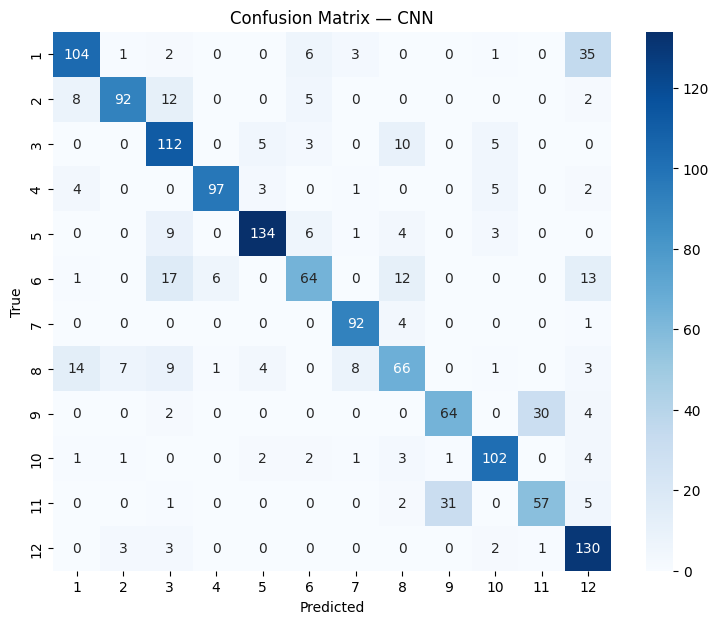

In [ ]:
y_pred_cnn = model_cnn.predict(X_test).argmax(axis=1) 
print(classification_report(y_test, y_pred_cnn, zero_division=0))

plt.figure(figsize=(9, 7))
sns.heatmap(confusion_matrix(y_test, y_pred_cnn), annot=True, fmt='d', cmap='Blues',
            xticklabels=range(1, 13), yticklabels=range(1, 13))
plt.title("Confusion Matrix — CNN")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


**Attempt 1 — results and a methodological issue found afterward.**

This first run used `validation_split=0.15` (same as the MLP) and a fixed
`epochs=30`, with no `EarlyStopping`. Test accuracy came out to **~77%** — already
below every other model (RF ~80%, KNN ~76%, MLP ~81–82%), and notably *below* the
`val_accuracy` (~83%) shown during training.

That gap is the tell. `validation_split` here doesn't respect repetition boundaries —
it carves off the last 15% of the *shuffled* training windows at random. Because
windows overlap 50% with their neighbors (10-sample step on a 20-sample window),
a shuffled random split can easily put a window in "validation" while a
near-duplicate, heavily overlapping window from the *same repetition* sits in
training. The model is then partially validated on data it has effectively already
half-seen — inflating `val_accuracy` relative to the real, repetition-disjoint test
set (`X_test`).

This is a genuine methodological gap between this run and the MLP's evaluation, even
though both nominally used `validation_split=0.15` — worth flagging explicitly rather
than letting the numbers stand uncommented. Attempt 2 below fixes it by carving out
whole repetitions for validation, the same principle already used for the train/test
split.

In [42]:
model_cnn_2 = keras.Sequential([
    layers.Input(shape=(20,10)),
    layers.Conv1D(16, kernel_size = 3, activation='relu'),
    layers.MaxPooling1D(pool_size = 2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(12, activation='softmax'),
])
model_cnn_2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

model_cnn_2.summary()

test_reps = [2, 5, 7, 10]
val_reps = [4, 9]
exclude_train_reps = test_reps + val_reps
train_mask = ~np.isin(rep, exclude_train_reps)
test_mask = np.isin(rep, test_reps)
val_mask = np.isin(rep, val_reps)

X_raw_train, X_raw_val, X_raw_test = X_raw[train_mask], X_raw[val_mask], X_raw[test_mask]
y_train, y_val, y_test = y[train_mask], y[val_mask], y[test_mask]

y_train = y_train - 1
y_test = y_test - 1
y_val = y_val - 1

X_raw_train_shuf, y_train_shuf = shuffle(X_raw_train, y_train, random_state=42)

model_cnn_2.fit(
    X_raw_train_shuf, 
    y_train_shuf, 
    validation_data=(X_raw_val, y_val),
    epochs=100, 
    batch_size=32,
    callbacks=[early_stop])

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 18, 16)         │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 9, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 144)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         9,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,556 (41.23 KB)

 Trainable params: 10,556 (41.23 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3121 - loss: 2.2385 - val_accuracy: 0.3718 - val_loss: 2.0195
Epoch 2/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4771 - loss: 1.7552 - val_accuracy: 0.4915 - val_loss: 1.5711
Epoch 3/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5548 - loss: 1.3963 - val_accuracy: 0.5954 - val_loss: 1.3046
Epoch 4/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6089 - loss: 1.1951 - val_accuracy: 0.6624 - val_loss: 1.1898
Epoch 5/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6429 - loss: 1.0706 - val_accuracy: 0.6624 - val_loss: 1.1071
Epoch 6/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6484 - loss: 1.0005 - val_accuracy: 0.6952 - val_loss: 1.0503
Epoch 7/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6942 - loss: 0.9278 - val_accuracy: 0.7407 - val_loss: 0.9959
Epoch 8/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7032 - loss: 0.8891 - val_accuracy: 0.7635 - v

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

           0       0.57      0.88      0.69       152
           1       0.96      0.71      0.82       119
           2       0.66      0.76      0.70       135
           3       0.93      0.84      0.88       112
           4       0.85      0.90      0.87       157
           5       0.90      0.48      0.62       113
           6       0.86      0.92      0.89        97
           7       0.70      0.55      0.62       113
           8       0.66      0.71      0.69       100
           9       0.78      0.77      0.78       117
          10       0.68      0.57      0.62        96
          11       0.72      0.78      0.75       139

    accuracy                           0.75      1450
   macro avg       0.77      0.74      0.74      1450
weighted avg       0.77      0.75      0.75      1450



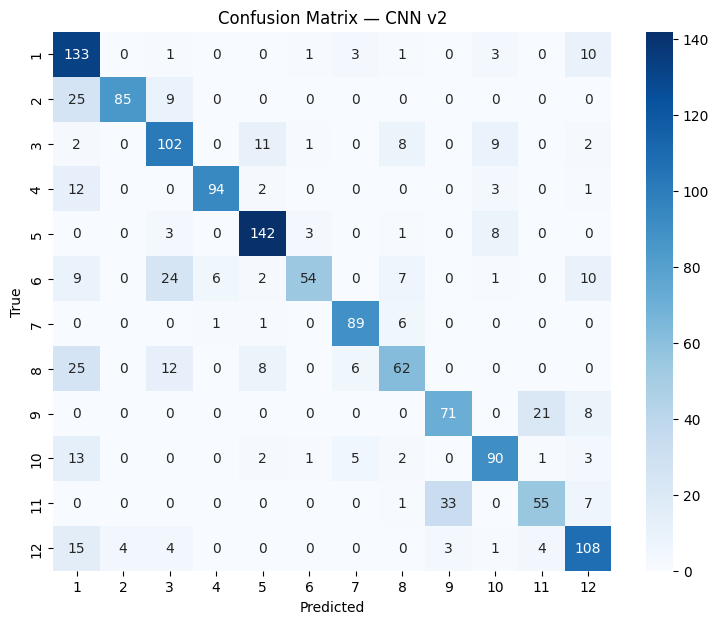

In [44]:
y_pred_cnn2 = model_cnn_2.predict(X_raw_test).argmax(axis=1) 
print(classification_report(y_test, y_pred_cnn2, zero_division=0))

plt.figure(figsize=(9, 7))
sns.heatmap(confusion_matrix(y_test, y_pred_cnn2), annot=True, fmt='d', cmap='Blues',
            xticklabels=range(1, 13), yticklabels=range(1, 13))
plt.title("Confusion Matrix — CNN v2")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## 12. Final Results, Limitations & Future Work

| Model | Test Accuracy | Notes |
|---|---|---|
| Random Forest | ~80% | Best classical baseline; robust to feature scale |
| KNN (k=5) | ~76% | Simple, sensitive to feature scaling |
| MLP | ~81–82% | Best overall; needed the shuffle fix to validate correctly |
| MLP + EarlyStopping | ~81% | Matches manually-tuned MLP; adds training robustness, not accuracy |
| CNN (raw signal, leaky validation) | ~77% | First attempt; validation split leaked overlapping windows |
| CNN (raw signal, leak-free + EarlyStopping) | ~75% | Weakest overall — see discussion below |

**Headline finding:** for this dataset (one subject, 10 repetitions/gesture, 10
electrodes), hand-crafted statistical features (mean/std/min/max/RMS per electrode)
consistently outperform an end-to-end CNN learning directly from the raw waveform.
This is a reasonable, literature-consistent outcome rather than a failure — with this
little data, decades of domain knowledge baked into the feature set currently outweighs
what a small CNN can discover on its own. A natural extension would be revisiting this
comparison with more subjects and repetitions, where a CNN's relative advantage
typically grows.

**Known limitation — gesture 9 (thumb adduction) vs. 11 (thumb flexion) confusion.**
This pair is consistently the most confused across *every model tested*, including the
architecturally very different CNN. That cross-model consistency is stronger evidence
than any single model's result: it points to a genuine anatomical/sensor-placement
limitation (overlapping intrinsic/extrinsic thumb muscle activity, see Section 7),
not an artifact of one model's quirks. Electrode 8 provides the clearest separation for
this specific pair; electrodes 4–6 carry almost no discriminative signal for thumb
movements at all, consistent with their placement being farther from thumb-controlling
muscles.

**Other limitations worth stating plainly:**
- Single subject (Subject 1 only) — no evidence yet on how well any of these models
  generalize to a different person's EMG, which the original NinaPro paper explicitly
  shows is a hard, mostly-unsolved problem (inter-subject accuracy barely above chance).
- Only 10 repetitions per gesture — the repetition-based splits used throughout are the
  methodologically correct choice to avoid leakage, but they're also coarse: holding out
  even one repetition for validation is a large chunk of an already-small dataset.
- The CNN architecture explored here is intentionally minimal (one conv layer) — a
  fair comparison at a larger data scale would likely need a deeper network, which was
  out of scope given the data available.

**Attempt 2 — leak-free validation, fresh model, EarlyStopping.**

Two repetitions (`val_reps = [4, 9]`) are held out from training and used as
`validation_data` directly, instead of letting Keras split (and potentially leak)
shuffled training windows. A fresh model (`model_cnn_2`, same architecture, freshly
initialized weights) is trained from scratch — reusing `model_cnn`'s already-trained
weights and continuing to train them would not be a fair comparison, same reasoning
as the MLP vs. MLP+EarlyStopping comparison in Section 9. `EarlyStopping` is added
with a generous `epochs=100` budget so it actually has room to decide when to stop,
rather than being capped by an arbitrary fixed count.

Training stopped at epoch 37 (`patience=8` on `val_loss`), and with
`restore_best_weights=True` the model's final weights are rolled back to whichever
epoch actually had the lowest `val_loss` — around epoch 29, not epoch 37 itself. This
is why the accuracy printed at the last training epoch doesn't necessarily match the
model that actually gets evaluated below; only `.predict()` on the real held-out
`X_raw_test` tells you what you've got.

**Result: ~75% test accuracy — still the weakest of all four models**, and slightly
*below* Attempt 1's (leaky) 77%. This is expected, not a regression to be chased:
fixing the leak also *shrank the training set* (6 repetitions → 4, since 2 are now
reserved for validation), on top of the CNN already needing more data than the
feature-based models to discover good filters from scratch with only one conv layer.

**Why not just tune it to do better?** With only 10 repetitions total from a single
subject, further architecture or hyperparameter tuning risks overfitting to this one
test split rather than genuinely improving the model — not a good trade against the
project's actual goal of a well-reasoned comparison, not a leaderboard score.